In [70]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
patient=pd.read_csv("patient_records_raw.csv")
print(patient.head(),"\n\n\n")
print(patient.describe(),"\n\n\n")
print(patient.shape,"\n\n\n")
print(patient.info(),"\n\n\n")

  patient_id             name   age  gender blood_type   bmi  bp_systolic  \
0      P1123       Rohit Shah  35.0  Female         A+  29.6        110.0   
1      P1442      Sneha Jones  21.0  Female         A+  28.0        145.0   
2      P0352  Hassan Williams  43.0    Male         O+  32.6        153.0   
3      P0353    Harper Thomas  33.0    Male         O+  24.6        165.0   
4      P0579     Daniel Jones  51.0    Male        AB-  28.0        109.0   

   bp_diastolic  heart_rate cholesterol  ...  stress_level  family_history  \
0          82.0        59.0      Normal  ...          High             Yes   
1         101.0        72.0  Borderline  ...        Medium             Yes   
2          78.0        79.0  Borderline  ...           Low             NaN   
3          61.0        58.0        High  ...           Low              No   
4         100.0       101.0      Normal  ...        Medium             Yes   

      diagnosis num_medications prev_hospitalizations risk_level    

In [53]:
patient.isnull().sum()

patient_id                 0
name                       0
age                       41
gender                    24
blood_type               138
bmi                       35
bp_systolic               25
bp_diastolic              26
heart_rate                26
cholesterol               52
glucose_level             32
hba1c                     30
smoking                   39
alcohol_consumption      577
exercise_habit           462
diet_quality              52
stress_level              49
family_history            38
diagnosis                709
num_medications           21
prev_hospitalizations     21
risk_level                 0
outcome                    0
admission_date            13
length_of_stay_days       21
hospital_bill_usd         30
dtype: int64

In [54]:
patient['bmi'] = pd.to_numeric(patient['bmi'], errors='coerce')

In [55]:
patient['age'] = patient['age'].fillna(patient['age'].median())
patient["bmi"]=patient["bmi"].fillna(patient["bmi"].median())
patient["bp_systolic"]=patient["bp_systolic"].fillna(patient["bp_systolic"].median())
patient["bp_diastolic"]=patient["bp_diastolic"].fillna(patient["bp_diastolic"].median())
patient["heart_rate"]=patient["heart_rate"].fillna(patient["heart_rate"].median())
patient["glucose_level"]=patient["glucose_level"].fillna(patient["glucose_level"].median())
patient["hba1c"]=patient["hba1c"].fillna(patient["hba1c"].median())
patient["num_medications"]=patient["num_medications"].fillna(patient["num_medications"].median())
patient["prev_hospitalizations"]=patient["prev_hospitalizations"].fillna(patient["prev_hospitalizations"].median())
patient['length_of_stay_days'] = patient['length_of_stay_days'].fillna(patient['length_of_stay_days'].median())
patient['hospital_bill_usd'] = patient['hospital_bill_usd'].fillna(patient['hospital_bill_usd'].median())

In [56]:
patient.isnull().sum()

patient_id                 0
name                       0
age                        0
gender                    24
blood_type               138
bmi                        0
bp_systolic                0
bp_diastolic               0
heart_rate                 0
cholesterol               52
glucose_level              0
hba1c                      0
smoking                   39
alcohol_consumption      577
exercise_habit           462
diet_quality              52
stress_level              49
family_history            38
diagnosis                709
num_medications            0
prev_hospitalizations      0
risk_level                 0
outcome                    0
admission_date            13
length_of_stay_days        0
hospital_bill_usd          0
dtype: int64

In [57]:
patient["gender"]=patient["gender"].fillna(patient["gender"].mode()[0])
patient["blood_type"]=patient["blood_type"].fillna(patient["blood_type"].mode()[0])
patient["cholesterol"]=patient["cholesterol"].fillna(patient["cholesterol"].mode()[0])
patient["smoking"]=patient["smoking"].fillna(patient["smoking"].mode()[0])
patient["alcohol_consumption"]=patient["alcohol_consumption"].fillna(patient["alcohol_consumption"].mode()[0])
patient["exercise_habit"]=patient["exercise_habit"].fillna(patient["exercise_habit"].mode()[0])
patient["diet_quality"]=patient["diet_quality"].fillna(patient["diet_quality"].mode()[0])
patient["stress_level"]=patient["stress_level"].fillna(patient["stress_level"].mode()[0])
patient["family_history"]=patient["family_history"].fillna(patient["family_history"].mode()[0])
patient["diagnosis"]=patient["diagnosis"].fillna("Unknown")
patient["admission_date"]=patient["admission_date"].fillna("Unknown")


In [58]:
def fix_outliers(df,column,min_value=0):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR=Q3-Q1
    lower=max(Q1-1.5*IQR,min_value)
    maximum=Q3 + 1.5*IQR
    df[column]=df[column].clip(lower,maximum)
    return df
    
all_column = [
    'age', 
    'bmi', 
    'bp_systolic', 
    'bp_diastolic', 
    'heart_rate', 
    'glucose_level', 
    'hba1c', 
    'num_medications', 
    'prev_hospitalizations',
    'length_of_stay_days',
    'hospital_bill_usd'
]
for col in all_column:
    patient=fix_outliers(patient,col)

In [59]:
patient = fix_outliers(patient, 'age', min_value=18)
patient = fix_outliers(patient, 'heart_rate', min_value=40)

In [60]:
patient.describe()

,age,bmi,bp_systolic,bp_diastolic,heart_rate,glucose_level,hba1c,num_medications,prev_hospitalizations,length_of_stay_days,hospital_bill_usd
count,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000
mean,51.134194,26.142548,136.194194,83.643226,79.401290,100.694581,5.650323,3.458065,2.457419,15.004516,14338.515772
std,20.227692,5.311825,27.248806,17.222497,14.479564,25.131680,1.162952,2.280347,1.678999,8.277193,13069.165947
min,18.000000,12.350000,90.000000,55.000000,40.000000,32.300000,2.650000,0.000000,0.000000,1.000000,9.740000
25%,34.000000,22.700000,112.000000,69.000000,67.000000,83.525000,4.900000,1.000000,1.000000,8.000000,4348.920000
50%,50.000000,26.200000,135.000000,84.000000,79.000000,101.000000,5.700000,3.000000,2.000000,15.000000,9932.740000
75%,68.000000,29.600000,160.000000,99.000000,92.000000,117.675000,6.400000,5.000000,4.000000,22.000000,21259.527500
max,119.000000,39.950000,184.000000,114.000000,129.500000,168.900000,8.650000,7.000000,5.000000,29.000000,46625.438750


In [61]:
patient = patient.drop_duplicates()

In [62]:
patient

,patient_id,name,age,gender,blood_type,bmi,bp_systolic,bp_diastolic,heart_rate,cholesterol,...,stress_level,family_history,diagnosis,num_medications,prev_hospitalizations,risk_level,outcome,admission_date,length_of_stay_days,hospital_bill_usd
0,P1123,Rohit Shah,35.0,Female,A+,29.6,110.0,82.0,59.0,Normal,...,High,Yes,Unknown,0.0,4.0,Medium,Recovered,2022-01-18,15.0,20939.84000
1,P1442,Sneha Jones,21.0,Female,A+,28.0,145.0,101.0,72.0,Borderline,...,Medium,Yes,Hypertension,5.0,1.0,Medium,Recovered,2022-03-09,20.0,46625.43875
2,P0352,Hassan Williams,43.0,Male,O+,32.6,153.0,78.0,79.0,Borderline,...,Low,No,Unknown,0.0,1.0,Medium,Ongoing,2023-10-22,6.0,10459.25000
3,P0353,Harper Thomas,33.0,Male,O+,24.6,165.0,61.0,58.0,High,...,Low,No,Obesity,6.0,4.0,Medium,Ongoing,2021-11-05,21.0,19262.78000
4,P0579,Daniel Jones,51.0,Male,AB-,28.0,109.0,100.0,101.0,Normal,...,Medium,Yes,Hypertension,4.0,4.0,Medium,Recovered,2021-06-18,22.0,28008.36000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1545,P1131,Arjun Wilson,33.0,Male,AB+,28.1,167.0,87.0,60.0,Normal,...,Medium,No,Hypertension,3.0,5.0,Medium,Ongoing,2022-07-05,5.0,8885.32000
1546,P1295,Harper Wilson,56.0,Male,A+,22.0,95.0,112.0,56.0,High,...,Medium,No,Hypertension,3.0,0.0,High,Recovered,2023-08-14,13.0,7155.54000
1547,P0861,Ahmed Anderson,40.0,Female,O+,30.0,148.0,109.0,99.0,Normal,...,High,No,Heart Disease,7.0,2.0,Medium,Ongoing,2021-10-31,9.0,4408.96000
1548,P1460,Rohit White,57.0,Male,O+,23.6,181.0,58.0,56.0,Normal,...,Medium,No,Unknown,6.0,4.0,Medium,Recovered,2023-02-18,18.0,14438.63000


In [72]:
patient.dtypes

patient_id                       object
name                             object
age                               int64
gender                           object
blood_type                       object
bmi                             float64
bp_systolic                     float64
bp_diastolic                    float64
heart_rate                      float64
cholesterol                      object
glucose_level                   float64
hba1c                           float64
smoking                          object
alcohol_consumption              object
exercise_habit                   object
diet_quality                     object
stress_level                     object
family_history                   object
diagnosis                        object
num_medications                   int64
prev_hospitalizations             int64
risk_level                       object
outcome                          object
admission_date           datetime64[ns]
length_of_stay_days               int64


In [67]:
flo_at = ["age", "num_medications", "prev_hospitalizations", "length_of_stay_days"]

for fl in flo_at:
    patient[fl] = patient[fl].astype(int)
patient["admission_date"]=pd.to_datetime(patient["admission_date"],errors="coerce")

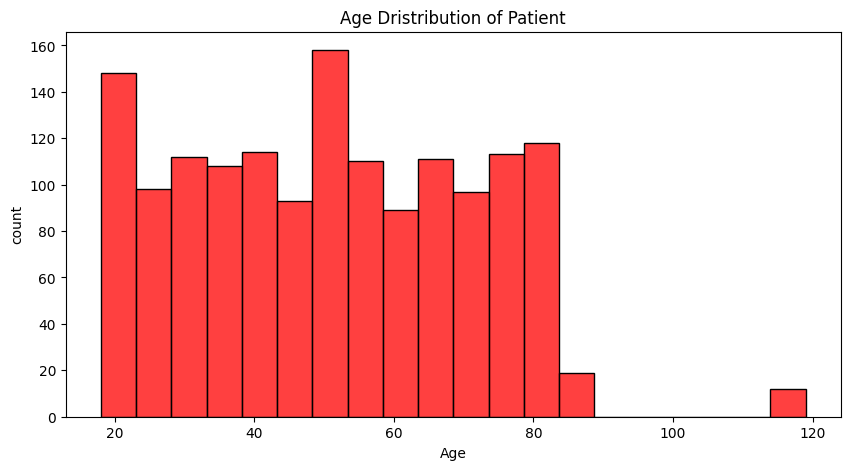

In [103]:
plt.figure(figsize=(10,5))
sns.histplot(patient["age"],bins=20,color="Red")
plt.title("Age Dristribution of Patient")
plt.xlabel("Age")
plt.ylabel("count")
plt.show()

/var/folders/6m/qm4yytdd1ql5xd4tkcvf2d880000gn/T/ipykernel_745/489860778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=patient["risk_level"],palette="Set2" , color="green")


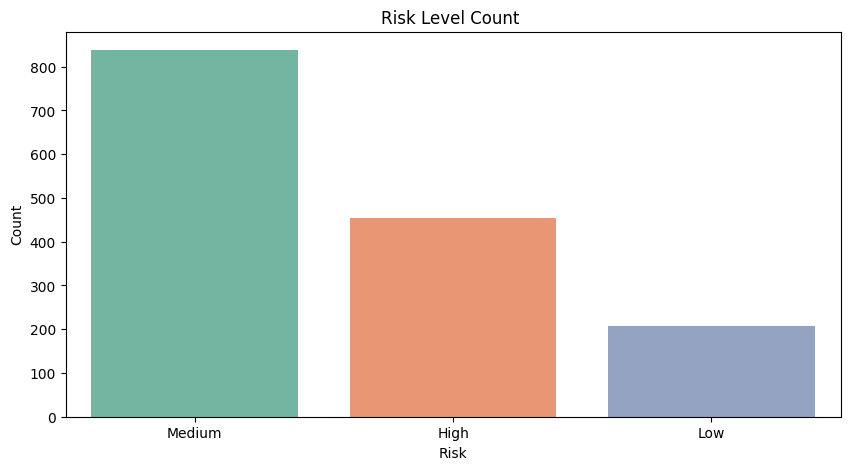

In [105]:
plt.figure(figsize=(10,5))
sns.countplot(x=patient["risk_level"],palette="Set2" , color="green")
plt.title("Risk Level Count ")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.show()

/var/folders/6m/qm4yytdd1ql5xd4tkcvf2d880000gn/T/ipykernel_745/1554153642.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=patient["diagnosis"], palette='Set1')


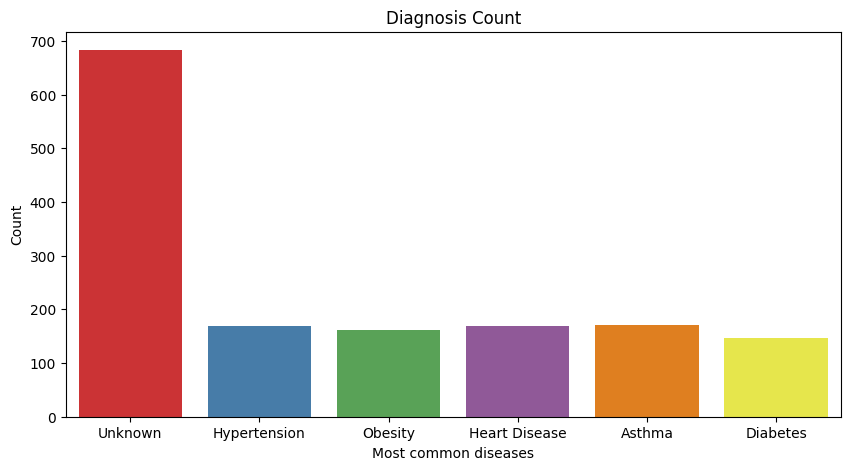

In [114]:
plt.figure(figsize=(10,5))
sns.countplot(x=patient["diagnosis"], palette='Set1')
plt.title("Diagnosis Count")
plt.xlabel("Most common diseases")
plt.ylabel("Count")
plt.show()

/var/folders/6m/qm4yytdd1ql5xd4tkcvf2d880000gn/T/ipykernel_745/1181349447.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(patient["hospital_bill_usd"], palette='Set1',color="red")


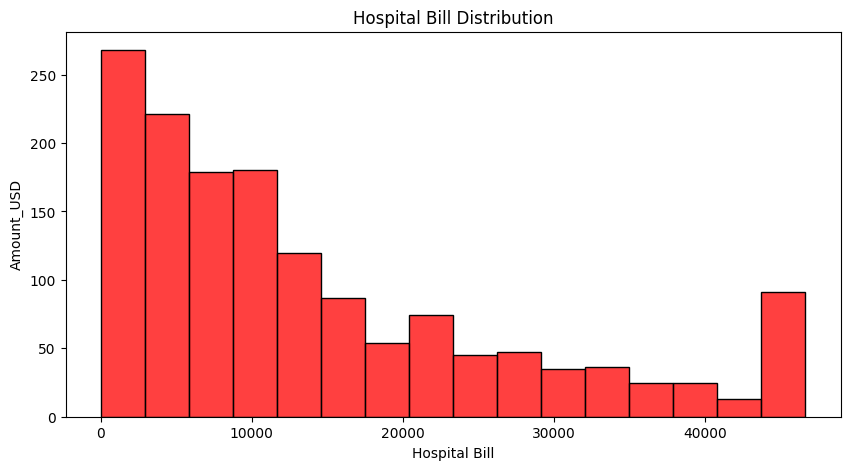

In [121]:
plt.figure(figsize=(10,5))
sns.histplot(patient["hospital_bill_usd"], palette='Set1',color="red")
plt.title("Hospital Bill Distribution")
plt.xlabel("Hospital Bill")
plt.ylabel("Amount_USD")
plt.show()

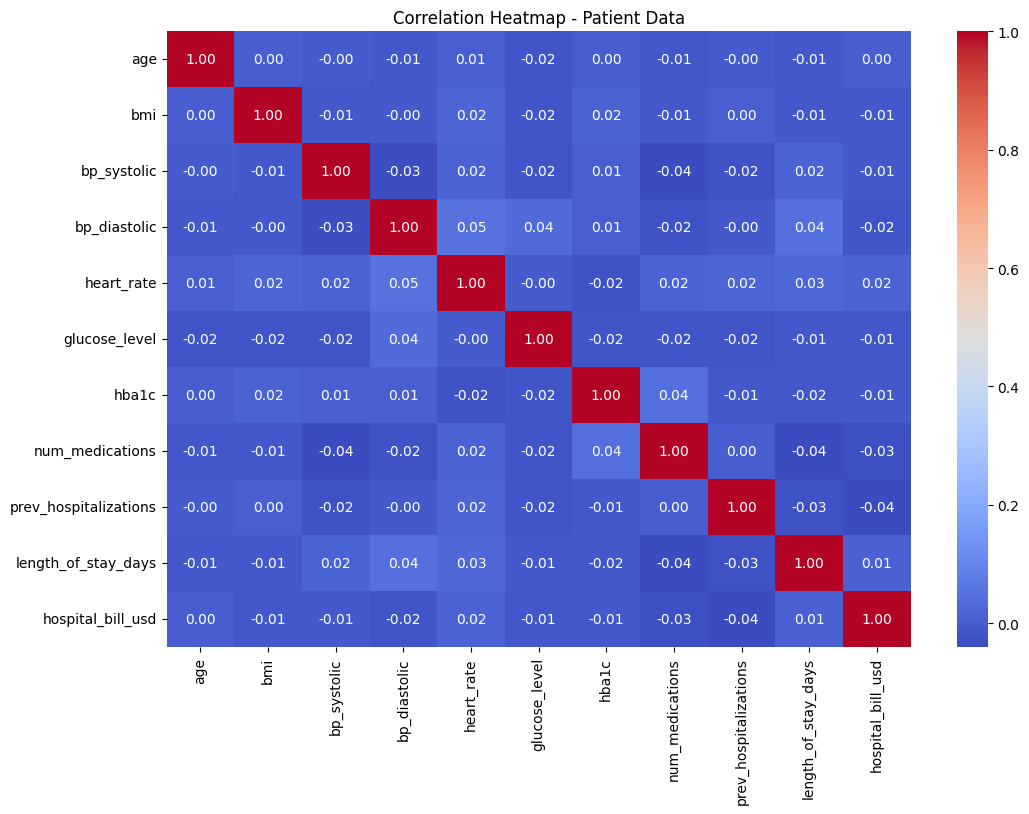

In [130]:
plt.figure(figsize=(12,8))
sns.heatmap(patient.corr(numeric_only=True), 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm')
plt.title('Correlation Heatmap - Patient Data')
plt.show()

In [131]:
patient.to_csv("patient_cleaned.csv", index=False)